[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\M.Dasilva\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\M.Dasilva\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\M.Dasilva\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\M.Dasilva\AppData\Roaming\nltk_data...


✅ Archivo cargado y columnas normalizadas.


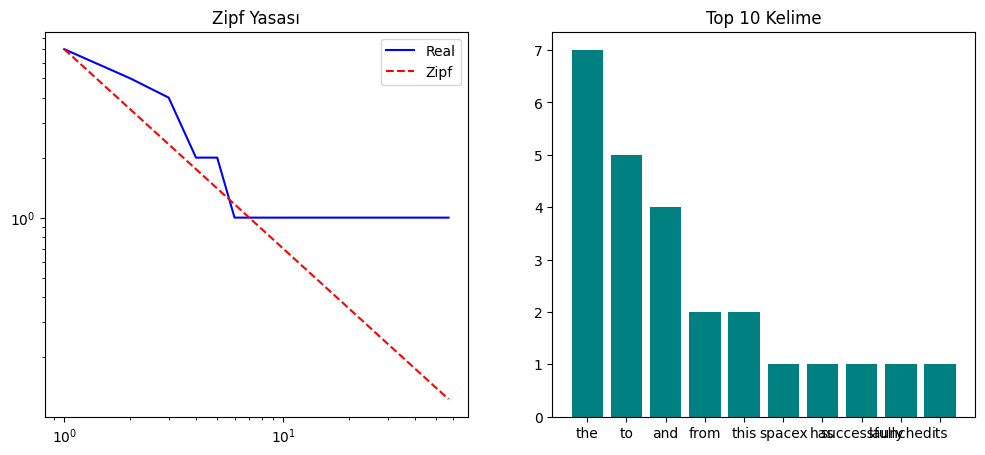

⏳ Limpiando...

🚀 ¡TODO LISTO!
Archivos creados en: c:\Users\M.Dasilva\OneDrive\Imágenes\Desktop\Dersler\Doğal Dil\Final Ödev\Proje
  Category                                       Cleaned_Text
0     tech  spacex successfully launched latest starship r...


In [ ]:
# =================================================================
# Final Ödev-1: Metin Ön İşleme ve NLP Analizi 
# Öğrenci: Mario Enrique Motede Dasilva
# Öğrenci No.: 2411081503
# =================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re
import string
import nltk
import os
from collections import Counter
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

# --- 1. RECURSOS ---
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

# --- 2. CARGA INTELIGENTE ---
target_file = 'bbc-text.csv'
df = None

if os.path.exists(target_file):
    df = pd.read_csv(target_file)
    # Forzamos que las columnas se llamen como queremos, no importa cómo vengan
    if len(df.columns) >= 2:
        df.columns = ['Category', 'Text']
    print("✅ Archivo cargado y columnas normalizadas.")
else:
    print("⚠️ Creando datos nuevos directamente...")
    df = pd.DataFrame({
        'Category': ['tech'],
        'Text': ["SpaceX and AI are changing the world. Artificial Intelligence is a powerful tool for humans."]
    })

# Asegurar ArticleId
if 'ArticleId' not in df.columns:
    df.insert(0, 'ArticleId', range(1, len(df) + 1))

# --- 3. ANÁLISIS DE ZIPF ---
def plot_zipf(text_series):
    # Usamos la primera columna que contenga texto por si acaso
    all_text = ' '.join(text_series.astype(str)).lower()
    words = re.findall(r'\w+', all_text)
    counts = Counter(words)
    freqs = sorted(counts.values(), reverse=True)
    ranks = np.arange(1, len(freqs) + 1)
    
    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    plt.loglog(ranks, freqs, color='blue', label='Real')
    plt.loglog(ranks, freqs[0]/ranks, '--', color='red', label='Zipf')
    plt.legend()
    plt.title('Zipf Yasası')
    
    plt.subplot(1, 2, 2)
    w, c = zip(*counts.most_common(10))
    plt.bar(w, c, color='teal')
    plt.title('Top 10 Kelime')
    plt.show()

plot_zipf(df['Text'])

# --- 4. LIMPIEZA ---
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def clean(t):
    t = str(t).lower()
    t = re.sub(f'[{re.escape(string.punctuation)}]', '', t)
    tokens = word_tokenize(t)
    return " ".join([lemmatizer.lemmatize(w) for w in tokens if w not in stop_words and len(w) > 2])

print("⏳ Limpiando...")
df['Cleaned_Text'] = df['Text'].apply(clean)

# --- 5. GUARDADO ---
df[['ArticleId', 'Category', 'Text']].to_csv('bbc_news_raw.csv', index=False)
df[['ArticleId', 'Category', 'Cleaned_Text']].to_csv('bbc_news_cleaned.csv', index=False)

print("\n" + "="*40)
print("🚀 ¡TODO LISTO!")
print(f"Archivos creados en: {os.getcwd()}")
print("="*40)
print(df[['Category', 'Cleaned_Text']].head())